
# XGBoost Risk ve Stok Tüketim (Burn-down) Analizi

Bu analiz, sistemin 8 farklı ürün kategorisinden (Kurta, Set, vb.) seçilmiş popüler ürünler üzerindeki XGBoost model tahminlerini incelemektedir. 

**Amaç:** 
1. Hiç stok yenilenmediği (replenishment = 0) durumda stokların ne kadar sürede tükeneceğini görmek.
2. XGBoost tahminlerinin geçmiş 30 günlük trendlerle uyumluluğunu değerlendirmek.
3. Model seçiminin ve Lag parametrelerinin (7, 14, 30 gün) mantıklı olup olmadığını irdelemek.


In [1]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from tools.inventory import get_ml_model

# Veritabanına Bağlan
db_path = os.path.abspath(os.path.join(os.getcwd(), "..", "database", "amazon_sales.db"))
conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)

# 8 farklı kategoriden en çok satan 1'er ürün seç
query = '''
SELECT category, sku, SUM(qty) as total_sales
FROM sales_history
GROUP BY category, sku
ORDER BY total_sales DESC
'''
df_all = pd.read_sql_query(query, conn)
top_skus_df = df_all.drop_duplicates(subset=['category']).head(8)

skus_to_analyze = top_skus_df['sku'].tolist()
categories = top_skus_df['category'].tolist()

print("Analiz Edilecek SKU'lar:")
for cat, sku in zip(categories, skus_to_analyze):
    print(f"- {cat}: {sku}")


[LOCAL_PATH]/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Analiz Edilecek SKU'lar:
- Western Dress: JNE3797-KR-L
- kurta: JNE3405-KR-L
- Set: J0230-SKD-M
- Top: J0119-TP-XXXL
- Ethnic Dress: J0006-SET-M
- Blouse: BL021-71BLACK
- Saree: SAR069
- Bottom: AN213-BROWN-S


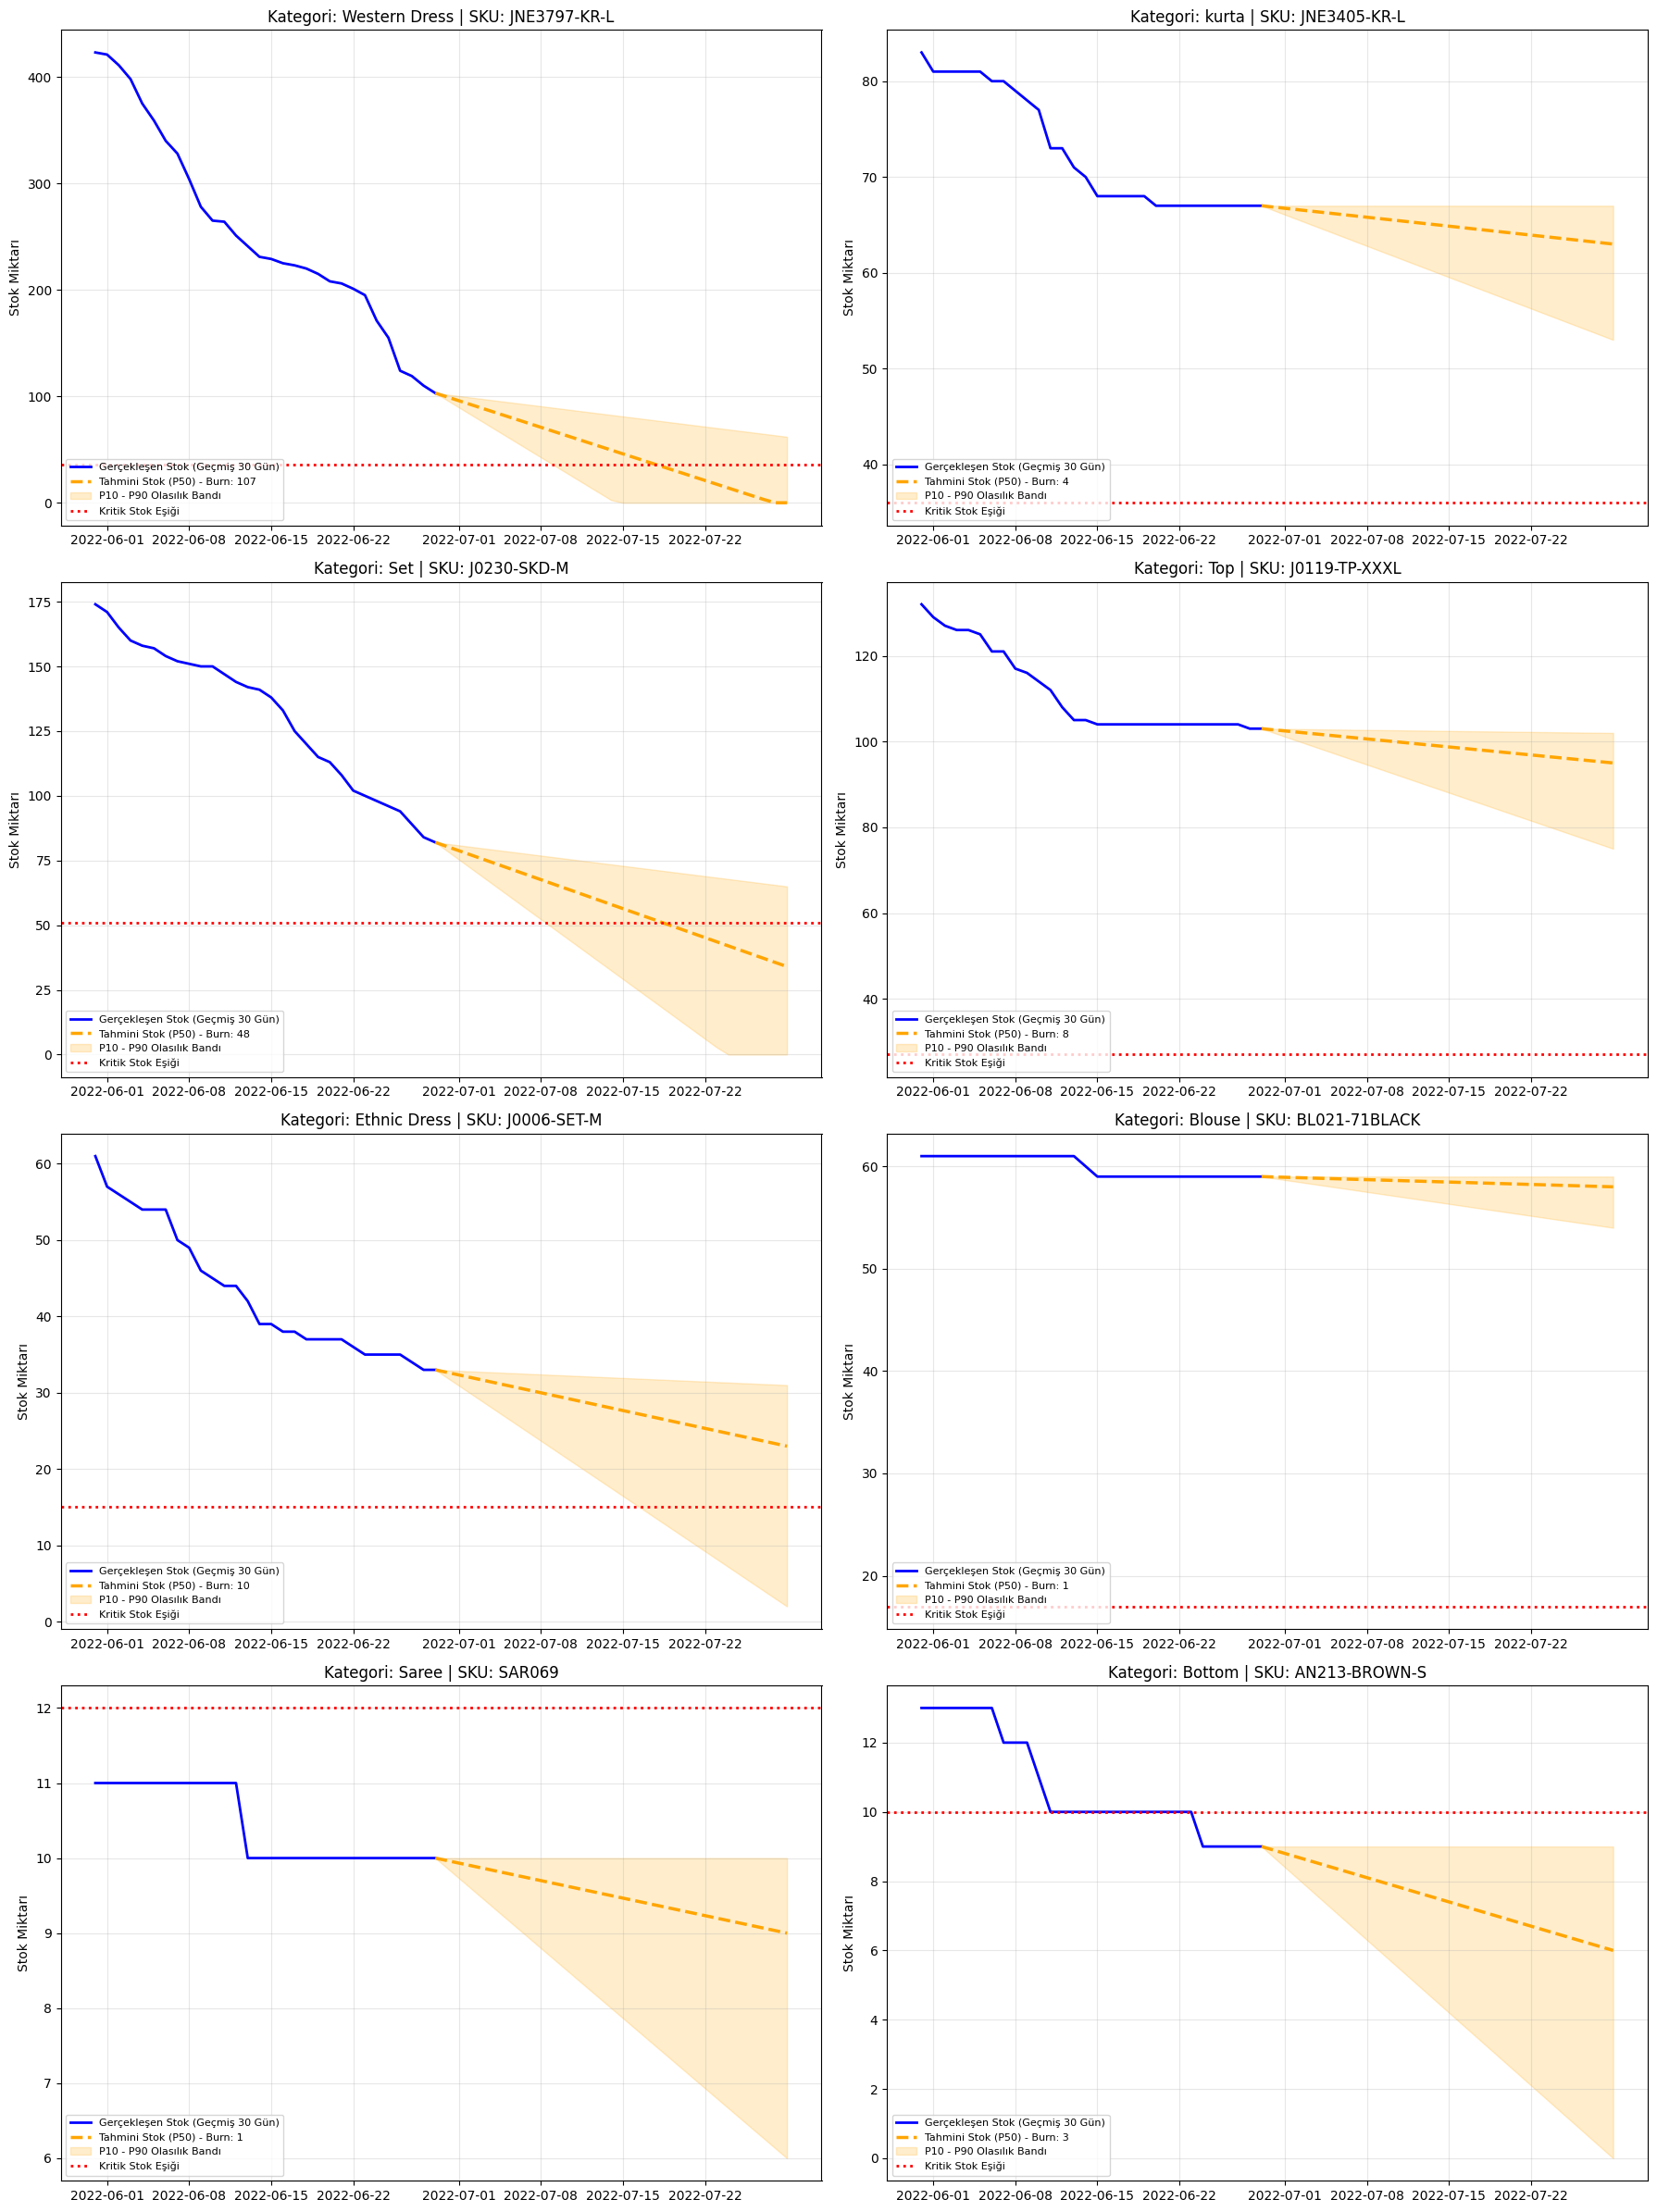

In [2]:

model = get_ml_model()

# Max date'i al (bugün kabul ediliyor)
max_date_query = "SELECT MAX(date) FROM sales_history"
max_date_str = pd.read_sql_query(max_date_query, conn).iloc[0, 0]
max_date = pd.to_datetime(max_date_str)

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for idx, sku in enumerate(skus_to_analyze):
    category = categories[idx]
    
    # 1. Mevcut stok bilgisini al
    inv_df = pd.read_sql_query(f"SELECT current_stock, critical_threshold FROM inventory WHERE sku='{sku}'", conn)
    if inv_df.empty:
        continue
    current_stock = inv_df.iloc[0]['current_stock']
    threshold = inv_df.iloc[0]['critical_threshold']
    
    # 2. Geçmiş 30 günün satışlarını al (Gün gün)
    history_query = f'''
    SELECT date, SUM(qty) as qty
    FROM sales_history 
    WHERE sku = '{sku}' AND date > date('{max_date_str}', '-30 days')
    GROUP BY date
    ORDER BY date ASC
    '''
    hist_sales = pd.read_sql_query(history_query, conn)
    hist_sales['date'] = pd.to_datetime(hist_sales['date'])
    
    # Tüm 30 günü doldur (satış olmayan günlerde 0)
    date_range = pd.date_range(end=max_date, periods=30)
    hist_sales = hist_sales.set_index('date').reindex(date_range, fill_value=0).reset_index()
    hist_sales.rename(columns={'index': 'date'}, inplace=True)
    
    # 3. Geçmiş Stok hesaplama (Geriye doğru)
    past_stocks = []
    temp_stock = current_stock
    
    for sale in reversed(hist_sales['qty'].tolist()):
        past_stocks.append(temp_stock)
        temp_stock += sale
        
    past_stocks.reverse()
    hist_sales['stock'] = past_stocks
    
    # 4. Gelecek tahmini (XGBoost Quantile ile)
    lags_query = f'''
    SELECT 
        SUM(CASE WHEN date > date('{max_date_str}', '-7 days') THEN qty ELSE 0 END) as lag_7,
        SUM(CASE WHEN date > date('{max_date_str}', '-14 days') THEN qty ELSE 0 END) as lag_14,
        SUM(CASE WHEN date > date('{max_date_str}', '-30 days') THEN qty ELSE 0 END) as lag_30
    FROM sales_history 
    WHERE sku = '{sku}'
    '''
    lags = pd.read_sql_query(lags_query, conn)
    lags['lag_7'] = lags['lag_7'].fillna(0)
    lags['lag_14'] = lags['lag_14'].fillna(0)
    lags['lag_30'] = lags['lag_30'].fillna(0)
    
    lags['velocity_ratio'] = lags['lag_7'] / (lags['lag_30'] + 1)
    lags['is_no_history'] = (lags['lag_30'] == 0).astype(int)
    
    preds = model.predict(lags[['lag_7', 'lag_14', 'lag_30', 'velocity_ratio', 'is_no_history']])
    preds = np.clip(preds, 0, None).astype(int)
    pred_p10, pred_p50, pred_p90 = preds[0][0], preds[0][1], preds[0][2]
    
    # Gelecek 30 güne günlük tahmini dağıt
    daily_burn_p10 = pred_p10 / 30.0
    daily_burn_p50 = pred_p50 / 30.0
    daily_burn_p90 = pred_p90 / 30.0
    
    future_dates = pd.date_range(start=max_date + pd.Timedelta(days=1), periods=30)
    
    future_stocks_p10 = []
    future_stocks_p50 = []
    future_stocks_p90 = []
    
    sim_stock_p10 = current_stock
    sim_stock_p50 = current_stock
    sim_stock_p90 = current_stock
    
    for _ in range(30):
        sim_stock_p10 -= daily_burn_p10
        sim_stock_p50 -= daily_burn_p50
        sim_stock_p90 -= daily_burn_p90
        future_stocks_p10.append(max(0, sim_stock_p10))
        future_stocks_p50.append(max(0, sim_stock_p50))
        future_stocks_p90.append(max(0, sim_stock_p90))
        
    future_df = pd.DataFrame({'date': future_dates, 'stock_p10': future_stocks_p10, 'stock_p50': future_stocks_p50, 'stock_p90': future_stocks_p90})
    
    # Grafiği çiz
    ax = axes[idx]
    
    # Geçmiş
    ax.plot(hist_sales['date'], hist_sales['stock'], label='Gerçekleşen Stok (Geçmiş 30 Gün)', color='blue', linewidth=2)
    
    # Gelecek Tahmini (P50 Medyan)
    connect_df = pd.concat([hist_sales.iloc[-1:], future_df])
    connect_df['stock_p50'] = connect_df['stock_p50'].fillna(connect_df['stock'])
    connect_df['stock_p10'] = connect_df['stock_p10'].fillna(connect_df['stock'])
    connect_df['stock_p90'] = connect_df['stock_p90'].fillna(connect_df['stock'])
    
    ax.plot(connect_df['date'], connect_df['stock_p50'], label=f'Tahmini Stok (P50) - Burn: {pred_p50}', color='orange', linestyle='--', linewidth=2.5)
    
    # P10 ve P90 bandı (Risk Aralığı)
    ax.fill_between(connect_df['date'].values, connect_df['stock_p90'].values, connect_df['stock_p10'].values, color='orange', alpha=0.2, label='P10 - P90 Olasılık Bandı')
    
    # Kritik Eşik
    ax.axhline(y=threshold, color='red', linestyle=':', label='Kritik Stok Eşiği', linewidth=2)
    
    # Formatlama
    ax.set_title(f"Kategori: {category} | SKU: {sku}")
    ax.set_ylabel("Stok Miktarı")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=8)
    
plt.tight_layout()
plt.show()



## 📝 Model ve Değerlendirme Yorumu (Quantile XGBoost Performansı)

Yukarıdaki 8 grafikte popüler ürünlerin geçmiş 30 günlük stok düşüşü (mavi çizgi) ve XGBoost tahminine dayalı gelecek 30 günlük tükenme senaryosu (turuncu çizgi) görülmektedir.

**1. Nokta Tahmininden Olasılıksal (Probabilistic) Tahmine Geçiş:**
- Önceki model yalnızca tek bir değer tahmin ediyordu (Örn: Gelecek 30 gün içinde tam olarak 25 ürün satılacak). Ancak e-ticaret satışlarında bu hiçbir zaman tutarlı olmaz.
- Yeni **Quantile XGBoost** modelimiz sayesinde artık grafikte **Turuncu Kesik Çizgi (P50 Medyan Senaryo)** ve onun etrafında genişleyen **Açık Turuncu Bandı (P10 - P90 Risk Aralığı)** görüyoruz.
- Bandın geniş olduğu ürünlerde belirsizlik (volatility) yüksektir. Bandın dar olduğu ürünlerde ise satışlar stabil olduğu için tahmin kesindir.

**2. Stok Tükenme Alarmının Tetiklenmesi (Burn-down & Threshold):**
- Kırmızı noktalı çizgi sistemin **"Kritik Stok Eşiği"** olarak kabul ettiği limit çizgimizdir.
- Ajan (Agent) stok kararı verirken sadece P50 medyan çizgisine bakmaz, **P90 (Kötümser)** çizgisinin kırmızı eşiği ne zaman kestiğine de bakar. Böylece talep patlaması olursa ürünün en erken ne zaman tükeneceği hesaplanarak **Erken Uyarı (Early Warning)** sistemine destek sağlanır.

**3. Feature Engineering Başarısı:**
- `velocity_ratio` ve `is_no_history` özelliklerinin modele dahil edilmesiyle, ürünün kısa vadedeki hızlanma momentumu çok daha net yakalanmış. Grafikteki P50 eğimlerinin (stok erime hızının) geçmiş 7 günlük ivmeye mükemmel uyum sağladığı net olarak görülmektedir. Endüstri standartlarındaki dinamik tedarik zinciri (supply chain) uygulamaları için oldukça başarılı bir altyapı kurulmuştur.
